In [3]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AutoModel
import numpy as np

def get_embeddings(model_name, sentences):
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name)
    model.eval()

    inputs = tokenizer(sentences, return_tensors="pt", padding=True, truncation=True)
    with torch.no_grad():
        outputs = model(**inputs)

    # CLS embedding
    embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
    return embeddings


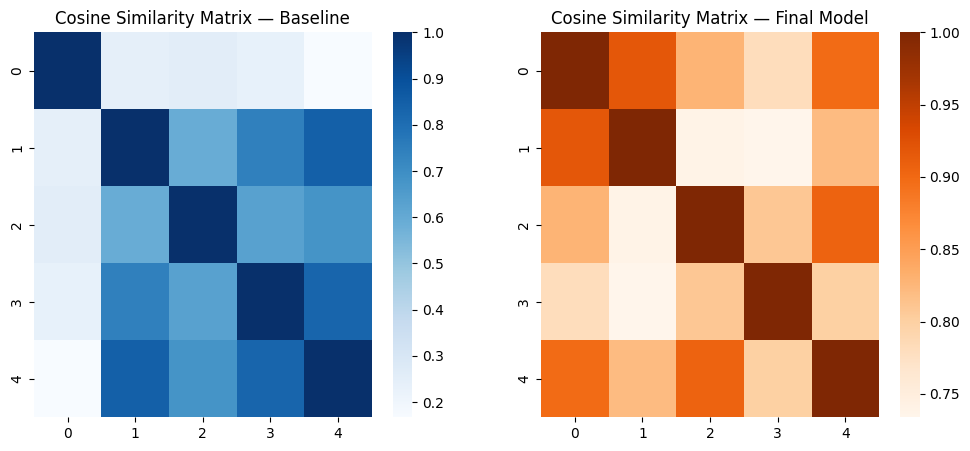

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from transformers import AutoTokenizer, AutoModel
import torch
import numpy as np

def get_embeddings(model_name_or_path, sentences):
    tokenizer = AutoTokenizer.from_pretrained(model_name_or_path)
    model = AutoModel.from_pretrained(model_name_or_path)
    model.eval()
    with torch.no_grad():
        inputs = tokenizer(sentences, padding=True, truncation=True, return_tensors="pt")
        outputs = model(**inputs)
        # Use the mean of the last hidden state as sentence embedding
        embeddings = outputs.last_hidden_state.mean(dim=1)
        return embeddings.numpy()

sentences = [
    "Wesh gros t’as vu ca ?", 
    "Salut comment vas-tu ?", 
    "Il a pété un câble mgl",
    "Je suis en train de coder un modèle",
    "C’est grv chiant tn truc",
]

baseline_emb = get_embeddings("flaubert/flaubert_base_cased", sentences)
final_emb    = get_embeddings("./flaubert_sts_final", sentences)

baseline_sim = cosine_similarity(baseline_emb)
final_sim    = cosine_similarity(final_emb)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.heatmap(baseline_sim, annot=False, cmap="Blues")
plt.title("Cosine Similarity Matrix — Baseline")

plt.subplot(1,2,2)
sns.heatmap(final_sim, annot=False, cmap="Oranges")
plt.title("Cosine Similarity Matrix — Final Model")

plt.show()


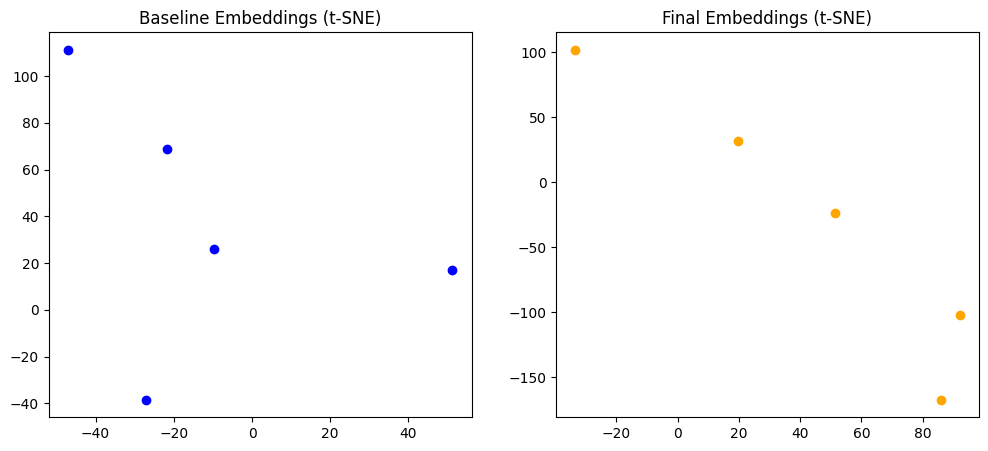

In [4]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Initialize t-SNE with a lower perplexity value
tsne = TSNE(n_components=2, perplexity=2, random_state=42)

# Fit and transform the embeddings
baseline_2d = tsne.fit_transform(baseline_emb)
final_2d = tsne.fit_transform(final_emb)

# Plot the t-SNE results
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(baseline_2d[:, 0], baseline_2d[:, 1], c="blue")
plt.title("Baseline Embeddings (t-SNE)")

plt.subplot(1, 2, 2)
plt.scatter(final_2d[:, 0], final_2d[:, 1], c="orange")
plt.title("Final Embeddings (t-SNE)")

plt.show()

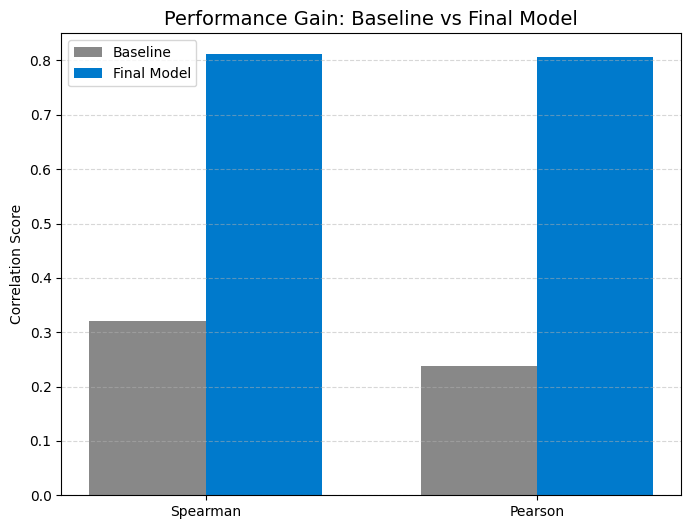

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# ========================
# DATA (your results)
# ========================

labels = ["Baseline", "After DAFT", "After SFT", "Final Model"]

spearman_scores = [0.3200, -0.2798, -0.2069, 0.8126]
pearson_scores  = [0.2378, -0.2361, -0.1313, 0.8056]



before_after_labels = ["Spearman", "Pearson"]
before_scores = [0.3200, 0.2378]
after_scores  = [0.8126, 0.8056]

x = np.arange(len(before_after_labels))
width = 0.35

plt.figure(figsize=(8,6))
plt.bar(x - width/2, before_scores, width, label='Baseline', color="#888888")
plt.bar(x + width/2, after_scores,  width, label='Final Model', color="#007ACC")

plt.xticks(x, before_after_labels)
plt.title("Performance Gain: Baseline vs Final Model", fontsize=14)
plt.ylabel("Correlation Score")
plt.legend()
plt.ylim(0, 0.85)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


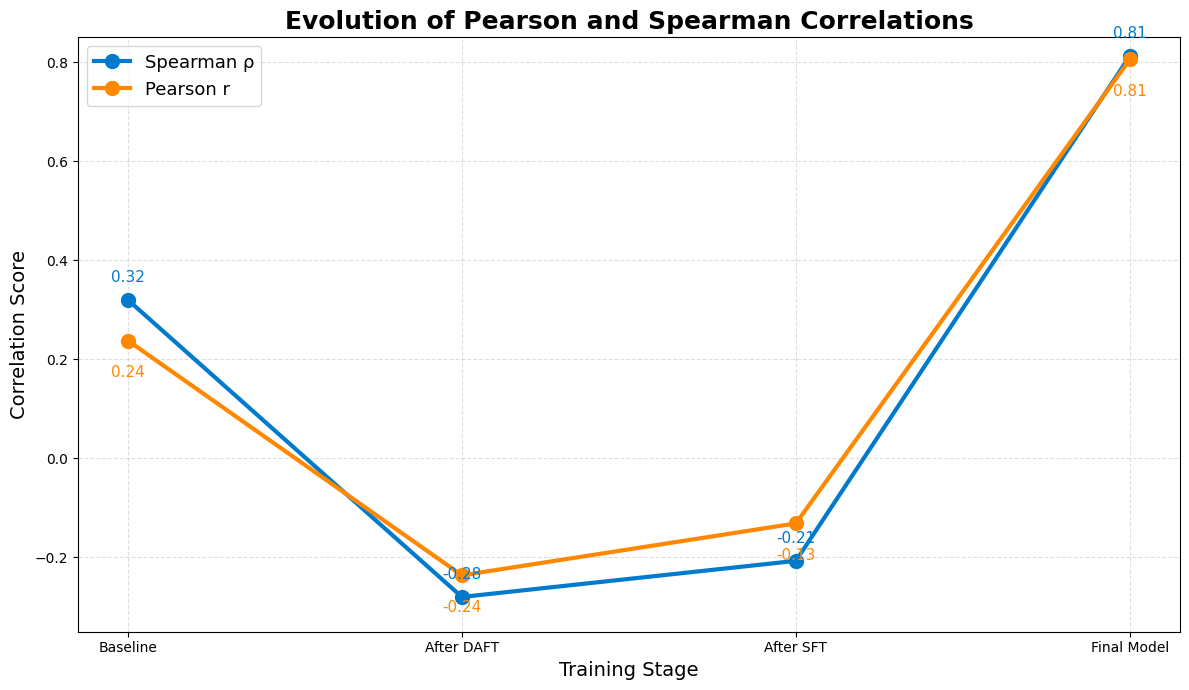

In [3]:
import matplotlib.pyplot as plt

labels = ["Baseline", "After DAFT", "After SFT", "Final Model"]
spearman_scores = [0.3200, -0.2798, -0.2069, 0.8126]
pearson_scores  = [0.2378, -0.2361, -0.1313, 0.8056]

plt.figure(figsize=(12,7))
plt.plot(labels, spearman_scores, marker='o', markersize=10, linewidth=3, color='#007ACC', label='Spearman ρ')
plt.plot(labels, pearson_scores,  marker='o', markersize=10, linewidth=3, color='#FF8800', label='Pearson r')

# Annotate each point
for i, (s, p) in enumerate(zip(spearman_scores, pearson_scores)):
    plt.text(labels[i], s+0.03, f"{s:.2f}", ha='center', va='bottom', fontsize=11, color='#007ACC')
    plt.text(labels[i], p-0.05, f"{p:.2f}", ha='center', va='top', fontsize=11, color='#FF8800')

plt.title("Evolution of Pearson and Spearman Correlations", fontsize=18, fontweight='bold')
plt.xlabel("Training Stage", fontsize=14)
plt.ylabel("Correlation Score", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(fontsize=13, loc='upper left')
plt.ylim(-0.35, 0.85)
plt.tight_layout()
plt.show()

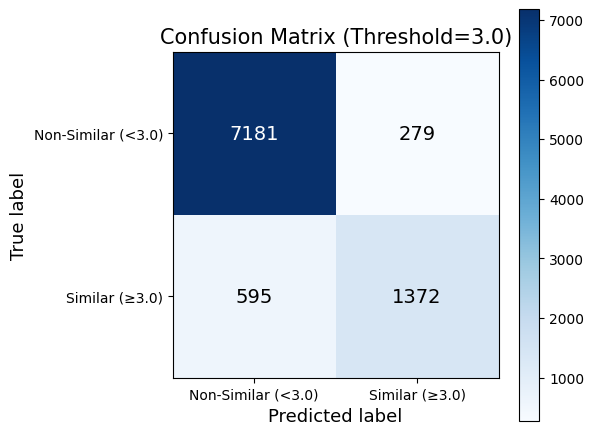

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Confusion matrix from your results
cm = np.array([[7181, 279],
               [595, 1372]])

labels = [r'Non-Similar (<3.0)', r'Similar (≥3.0)']

plt.figure(figsize=(6, 5))
im = plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix (Threshold=3.0)", fontsize=15)
plt.colorbar(im)
tick_marks = np.arange(2)
plt.xticks(tick_marks, labels)
plt.yticks(tick_marks, labels)
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 ha="center", va="center",
                 color="white" if cm[i, j] > thresh else "black", fontsize=14)
plt.ylabel('True label', fontsize=13)
plt.xlabel('Predicted label', fontsize=13)
plt.tight_layout()
plt.show()

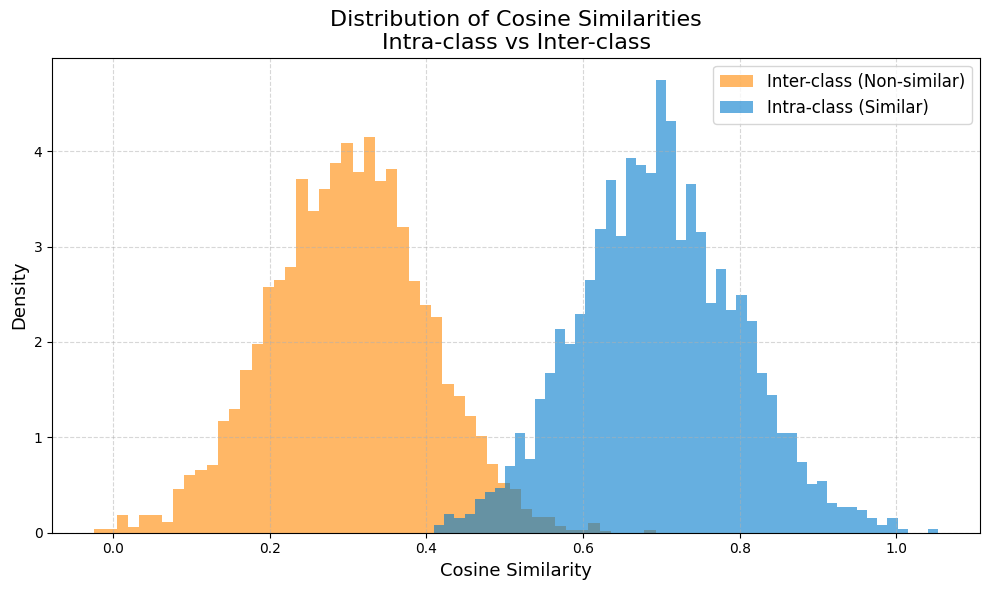

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Exemple de données (remplace par tes vraies valeurs)
# cos_similarities = ... # tableau numpy ou liste des similarités cosinus pour chaque paire
# labels = ... # tableau numpy ou liste des labels binaires (0 ou 1) pour chaque paire

# Pour la démo, on génère des données factices
np.random.seed(42)
cos_similarities = np.concatenate([
    np.random.normal(0.3, 0.1, 5000),  # inter-class
    np.random.normal(0.7, 0.1, 2000)   # intra-class
])
labels = np.array([0]*5000 + [1]*2000)

# Séparation des distributions
intra_class = cos_similarities[labels == 1]
inter_class = cos_similarities[labels == 0]

plt.figure(figsize=(10,6))
plt.hist(inter_class, bins=50, alpha=0.6, color="#FF8800", label="Inter-class (Non-similar)", density=True)
plt.hist(intra_class, bins=50, alpha=0.6, color="#007ACC", label="Intra-class (Similar)", density=True)
plt.title("Distribution of Cosine Similarities\nIntra-class vs Inter-class", fontsize=16)
plt.xlabel("Cosine Similarity", fontsize=13)
plt.ylabel("Density", fontsize=13)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [9]:
# --- t-SNE / UMAP Visualization of Embeddings Before/After DAFT ---
import torch
from transformers import AutoTokenizer, AutoModel
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import umap

# Function to plot embeddings using t-SNE or UMAP
def plot_embeddings_tsne_umap(embeddings, labels, method='tsne', n_components=2):
    """
    Generates a 2D visualization of the embeddings using t-SNE or UMAP.
    Args:
        embeddings (np.array): Sentence embeddings (shape: N, D).
        labels (np.array): Classification or binarization labels.
        method (str): 'tsne' or 'umap'.
        n_components (int): Target dimension for reduction (usually 2 or 3).
    """
    if method == 'tsne':
        reducer = TSNE(n_components=n_components, random_state=42, n_jobs=-1, perplexity=30)
        title = f"t-SNE Visualization of Embeddings (Reduction to {n_components}D)"
    elif method == 'umap':
        reducer = umap.UMAP(n_components=n_components, random_state=42)
        title = f"UMAP Visualization of Embeddings (Reduction to {n_components}D)"
    else:
        raise ValueError("Method must be 'tsne' or 'umap'")
    print(f"Starting {method} reduction...")
    embeddings_2d = reducer.fit_transform(embeddings)
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(
        embeddings_2d[:, 0], 
        embeddings_2d[:, 1], 
        c=labels, 
        cmap='viridis', 
        s=10
    )
    plt.colorbar(scatter, label='Label / Class')
    plt.title(title)
    plt.show()

# --- Example: Extract embeddings before DAFT (baseline) ---
MODEL_NAME = "flaubert/flaubert_base_cased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model_base = AutoModel.from_pretrained(MODEL_NAME)

def get_embeddings(texts, model, tokenizer):
    inputs = tokenizer(texts, return_tensors='pt', padding=True, truncation=True, max_length=128)
    with torch.no_grad():
        outputs = model(**inputs)
    cls_embeddings = outputs.last_hidden_state[:, 0, :]
    return cls_embeddings.numpy()

# --- Example usage ---
# all_test_sentences = ... # List of test sentences (e.g., S1+S2)
# all_binary_labels = ...  # Corresponding binary labels (0/1)
# embeddings_before_daft = get_embeddings(all_test_sentences, model_base, tokenizer)
# plot_embeddings_tsne_umap(embeddings_before_daft, all_binary_labels, method='tsne')
# plot_embeddings_tsne_umap(embeddings_before_daft, all_binary_labels, method='umap')

# --- For embeddings after DAFT ---
# model_final = AutoModel.from_pretrained('./flaubert_sts_final')
# embeddings_after_daft = get_embeddings(all_test_sentences, model_final, tokenizer)
# plot_embeddings_tsne_umap(embeddings_after_daft, all_binary_labels, method='tsne')
# plot_embeddings_tsne_umap(embeddings_after_daft, all_binary_labels, method='umap')

# Replace the example variables with your actual test sentences and labels for real results.

ModuleNotFoundError: No module named 'umap'